# Importing Libraries


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.set_option('display.max_rows', 100)  # Set this to however many rows you want to see



# Loading the CSV


In [2]:
df=pd.read_csv(r"C:\Users\Anus\PycharmProjects\Files\Healtcaare 2\healthcare_dataset.csv")

# Performing Functions

In [3]:
df.head()


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


### Starting the EDA process


In [4]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [5]:
df.tail()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal
55499,jAMES GARCiA,53,Female,O+,Arthritis,2024-04-02,Dennis Warren,Henry Sons and,Aetna,4010.134172,448,Urgent,2024-04-29,Ibuprofen,Abnormal


#### Checking for the shape, Data-types and statistical summary of the data

In [6]:
df.shape

(55500, 15)

In [7]:
df.dtypes

Name                   object
Age                     int64
Gender                 object
Blood Type             object
Medical Condition      object
Date of Admission      object
Doctor                 object
Hospital               object
Insurance Provider     object
Billing Amount        float64
Room Number             int64
Admission Type         object
Discharge Date         object
Medication             object
Test Results           object
dtype: object

In [8]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


##### Checking for the summary of the data

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

##### The data needs some tailoring need to made in the perfect order before we start the EDA process and start applying Machine Learning to get the insights

In [10]:
#if we see in the name column the names are not in the perfect order which need to be changed

In [11]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [12]:
#Using the .str.title() method which will standardize the names in the perfect capitalization order
df['Name']=df['Name'].str.title()

In [13]:
#Now we can see that the names are in the perfect order
df.head()


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## Checking for duplicated values and null values

In [14]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
55495    False
55496    False
55497    False
55498    False
55499    False
Length: 55500, dtype: bool

In [15]:
df.duplicated().sum()

np.int64(534)

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.isna().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [18]:
df.dropna()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55495,Elizabeth Jackson,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,Kyle Perez,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,Heather Wang,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,Jennifer Jones,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal


In [19]:
#The Data is clean from duplicated values aswell as na values, now we will change the data types of the columns that need to changed.

#### Changing Data-Types

In [20]:
df.head(5)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [21]:
# Column named Date of Admission and Discharge date need to be changed from object timedate type

##### Data Types Changing

In [22]:
#Column 1
df['Date of Admission']=pd.to_datetime(df['Date of Admission'], format='%Y-%m-%d')
#Column 2
df['Discharge Date']=pd.to_datetime(df['Discharge Date'], format='%Y-%m-%d')

In [23]:
df.dtypes

Name                          object
Age                            int64
Gender                        object
Blood Type                    object
Medical Condition             object
Date of Admission     datetime64[ns]
Doctor                        object
Hospital                      object
Insurance Provider            object
Billing Amount               float64
Room Number                    int64
Admission Type                object
Discharge Date        datetime64[ns]
Medication                    object
Test Results                  object
dtype: object

In [24]:
# The data is clean from duplicated values and all the columns are in the perfect order with the correct data-type
# From this we can now create our EDA Prcoess

# Medical Condition by Gender

<Axes: xlabel='Medical Condition', ylabel='Age'>

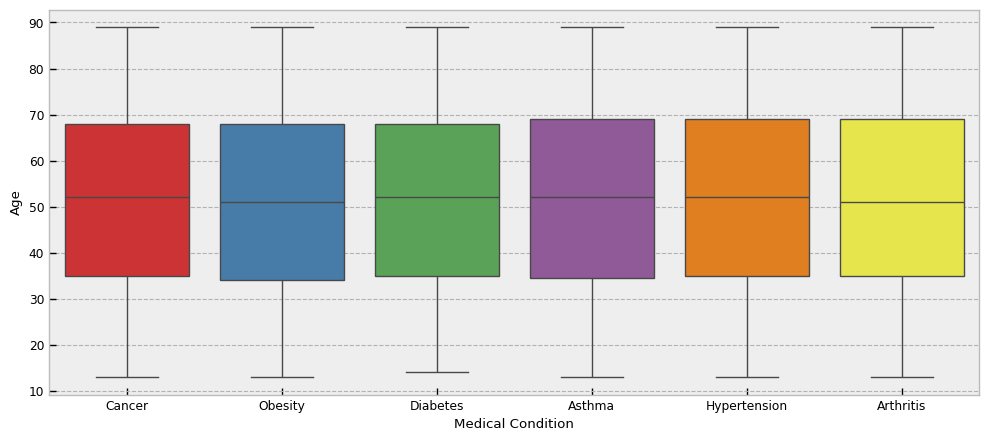

In [25]:
# Medical condition by Admission Type using Box plot
plt.figure(figsize=(12,5))
plt.style.use('bmh')
sns.set_context('paper')
sns.boxplot(df, x='Medical Condition', y='Age', palette='Set1')

# Medical condtion by Gender

In [26]:
df.head(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [27]:
# Making a dataframe named Medical_gender and performing the counts too see how many medical conditons are related to the gender counts
medical_gender= df.groupby(['Medical Condition','Gender']).size().reset_index(name='Counts')
medical_gender

,Medical Condition,Gender,Counts
0,Arthritis,Female,4642
1,Arthritis,Male,4576
2,Asthma,Female,4511
3,Asthma,Male,4584
4,Cancer,Female,4566
5,Cancer,Male,4574
6,Diabetes,Female,4609
7,Diabetes,Male,4607
8,Hypertension,Female,4569
9,Hypertension,Male,4582


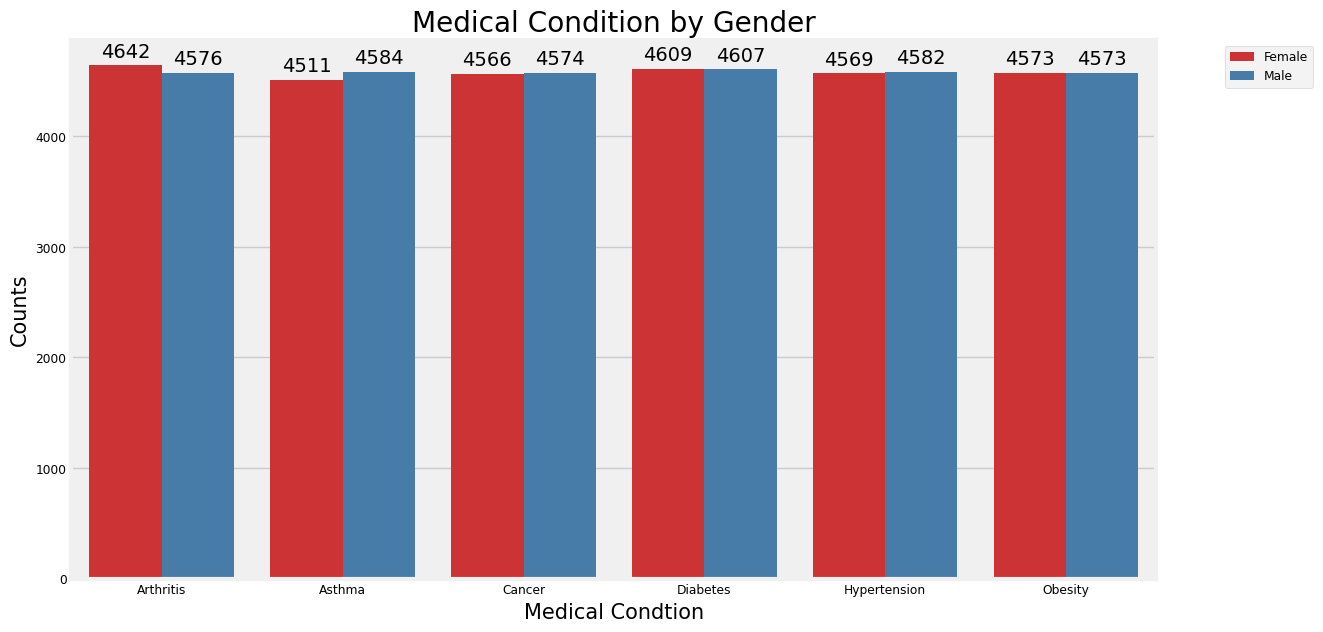

In [28]:
#plotting a bar plot to undesrtand the above finding
plt.figure(figsize=(14,7))
plt.style.use('fivethirtyeight')
ax=sns.barplot(medical_gender,x='Medical Condition', y='Counts', hue='Gender', palette='Set1')
plt.title('Medical Condition by Gender')
plt.xlabel('Medical Condtion', fontsize=15)
plt.ylabel('Counts', fontsize=15)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge', padding=3)
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

# Best Insurance provider by the billing Amount

In [29]:
# Making a new data frame named Insurance_billed to see how the insurance providers covered the Billing maount
insurance_billed= df.groupby('Insurance Provider')['Billing Amount'].mean().reset_index()
insurance_billed


,Insurance Provider,Billing Amount
0,Aetna,25549.689648
1,Blue Cross,25603.460603
2,Cigna,25525.998670
3,Medicare,25628.320208
4,UnitedHealthcare,25414.506208


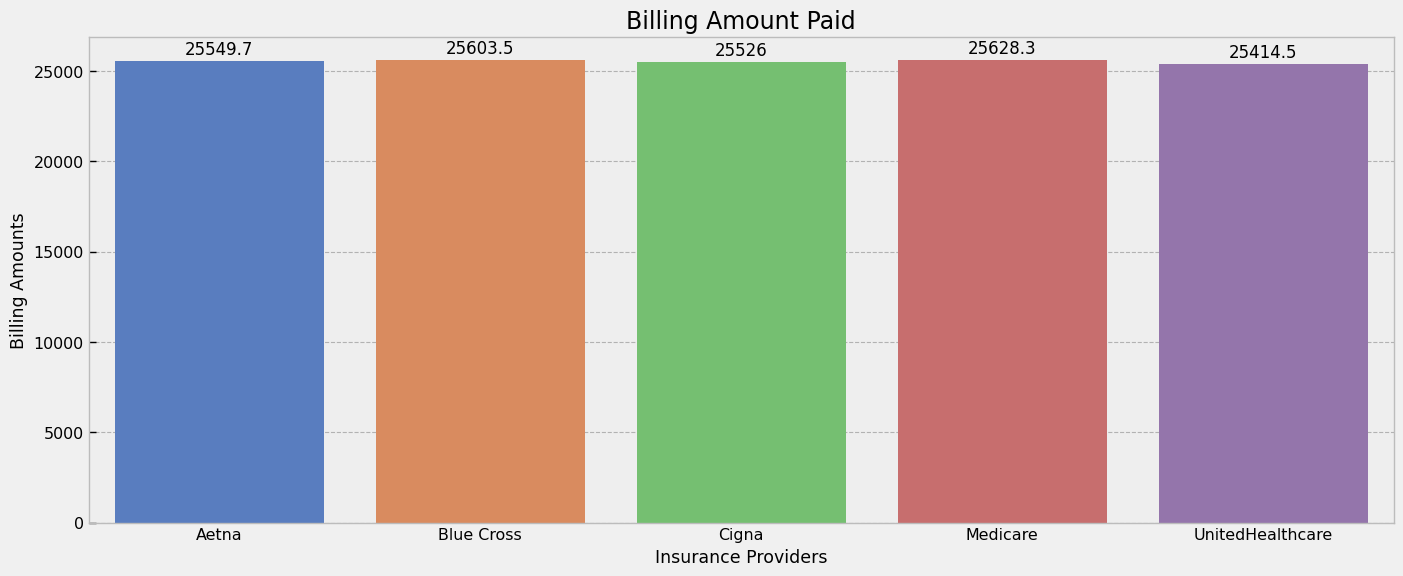

In [30]:
# Bar Plot for the Insruance provider with the billing amount paid by them
plt.figure(figsize=(15,6))
plt.style.use('bmh')
sns.set_context('paper', font_scale=1.3)
ax=sns.barplot(insurance_billed, x="Insurance Provider", y='Billing Amount', palette='muted')

for container in ax.containers:
    ax.bar_label(container, fontsize=12, padding=2)
plt.title('Billing Amount Paid', fontsize=17)
plt.xlabel("Insurance Providers")
plt.ylabel('Billing Amounts')
plt.show()


# Monthly Admission by admission Type
#### Shows what months were the most busy depending on the admission type


In [31]:

#Finding the month from Date of Admission and than using motnths to see when were there most patients admitted in hospital by Admission type
df['Months']=df['Date of Admission'].dt.month
df.head(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Months
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,1
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,8
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,9
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,11
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,9


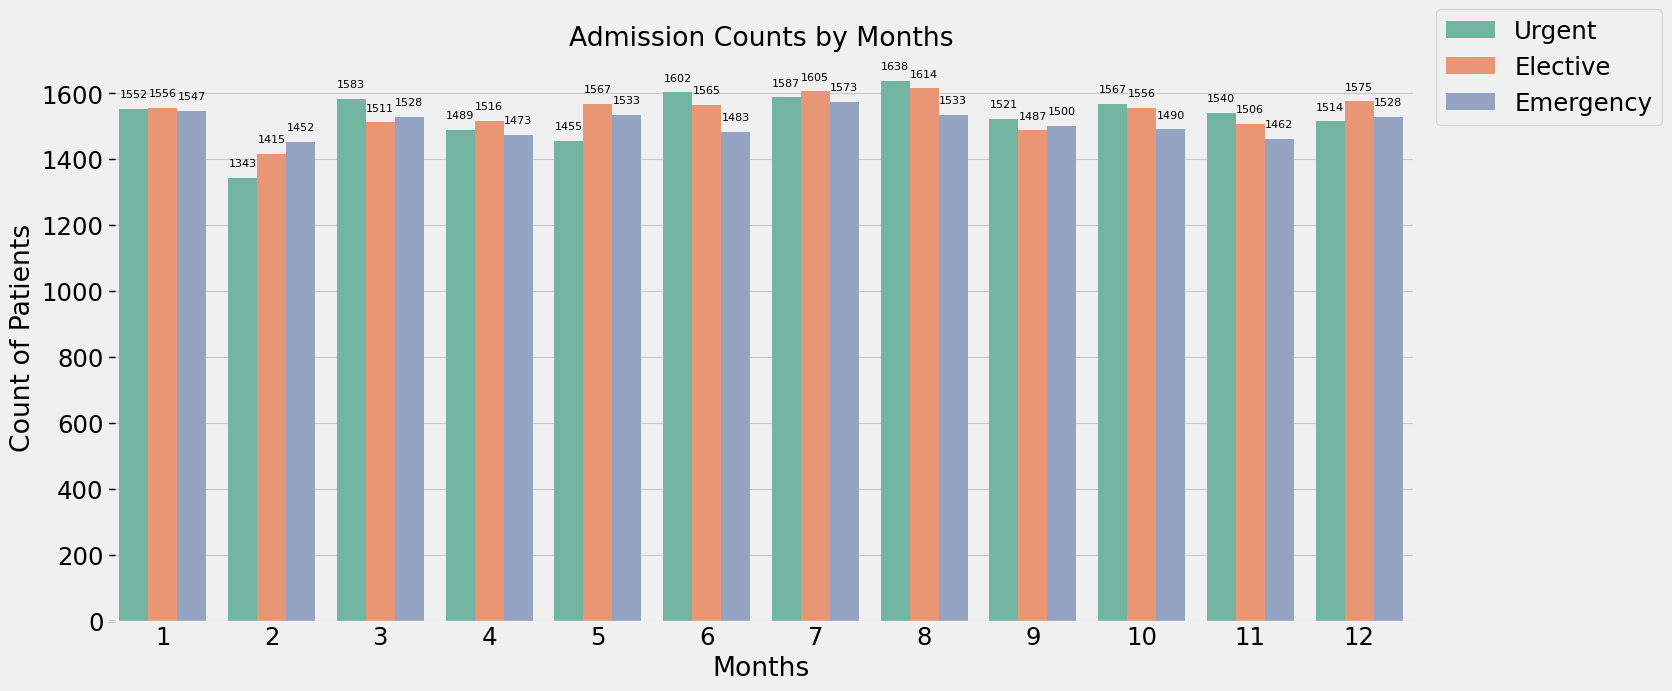

In [32]:
#plotting a bar grapgh throug which we will see the number of admission done in the hospitals on the basis of admission types
plt.figure(figsize=(15,7))
plt.style.use('fivethirtyeight')
sns.set_context('paper', font_scale=2)
ax=sns.countplot(df, x='Months', hue='Admission Type', palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fontsize=8,padding=7)
plt.title('Admission Counts by Months')
plt.xlabel('Months')
plt.ylabel('Count of Patients')
plt.legend(loc='upper right', bbox_to_anchor=(1.2,1.1))

plt.show()



# Medical Conditon by Gender
  #### Shows how genders are diagnosed by Medical Condition

In [33]:
medical_gender=df.groupby(['Medical Condition','Gender']).size().reset_index(name="Counts")
medical_gender

,Medical Condition,Gender,Counts
0,Arthritis,Female,4642
1,Arthritis,Male,4576
2,Asthma,Female,4511
3,Asthma,Male,4584
4,Cancer,Female,4566
5,Cancer,Male,4574
6,Diabetes,Female,4609
7,Diabetes,Male,4607
8,Hypertension,Female,4569
9,Hypertension,Male,4582


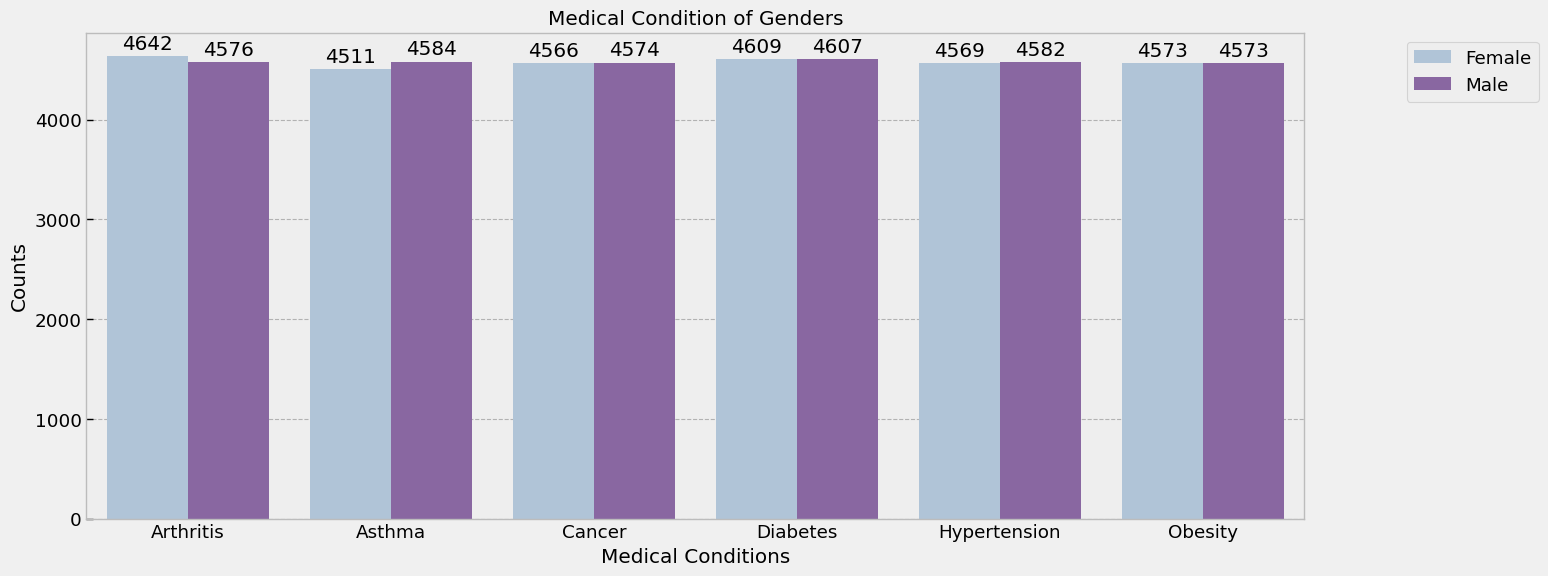

In [34]:
#Plotting a bar grapgh to understand the counts of Medical conditon by the genders, it will help us how a specif disease was found in certain gender
plt.figure(figsize=(14,6))
plt.style.use('bmh')
sns.set_context('paper', font_scale=1.5)
ax=sns.barplot(medical_gender, x='Medical Condition', y='Counts', hue='Gender', palette='BuPu')
for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.title('Medical Condition of Genders')
plt.xlabel('Medical Conditions')
plt.ylabel('Counts')
plt.legend(loc='upper right', bbox_to_anchor=(1.2,1))
plt.show()

# Top Medications by Medical Condition

In [35]:
medication=df.groupby(['Medication', 'Medical Condition']).size().reset_index(name='Counts')
medication

,Medication,Medical Condition,Counts
0,Aspirin,Arthritis,1901
1,Aspirin,Asthma,1781
2,Aspirin,Cancer,1768
3,Aspirin,Diabetes,1836
4,Aspirin,Hypertension,1845
5,Aspirin,Obesity,1853
6,Ibuprofen,Arthritis,1805
7,Ibuprofen,Asthma,1802
8,Ibuprofen,Cancer,1862
9,Ibuprofen,Diabetes,1846


# Billing Amount by Admission Type


In [36]:
billing_amount=df.groupby('Admission Type')['Billing Amount'].mean().reset_index()
billing_amount


,Admission Type,Billing Amount
0,Elective,25612.139673
1,Emergency,25505.332240
2,Urgent,25514.532045


# Most Common Blood Types

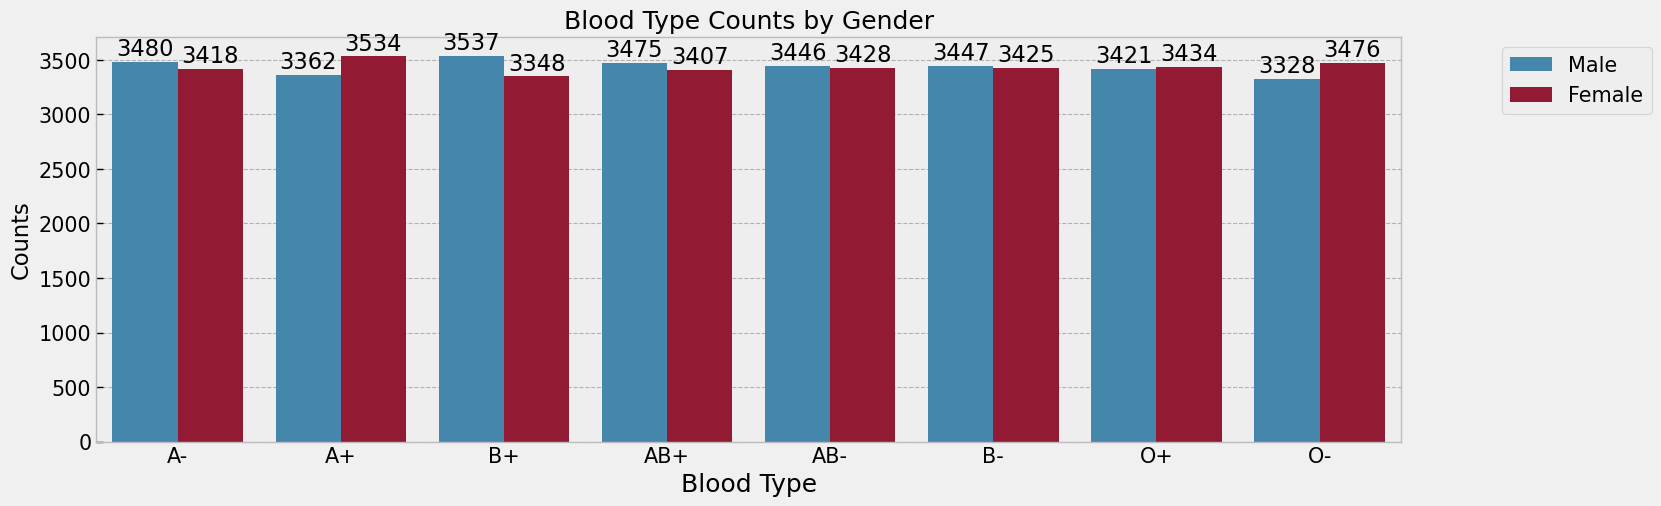

In [37]:
# Using a bar chart to see the blood types, with this we can understand about the nature of the patients

plt.figure(figsize=(15,5))
plt.style.use('bmh')
sns.set_context('paper', font_scale=1.7)
ax=sns.countplot(df,x='Blood Type', order=df['Blood Type'].value_counts().index, hue='Gender')

for container in ax.containers:
    ax.bar_label(container, padding=1 )
plt.legend(loc='upper right',bbox_to_anchor=(1.2,1))

plt.title('Blood Type Counts by Gender', fontsize=18)
plt.xlabel('Blood Type', fontsize=18)
plt.ylabel('Counts')
plt.show()


# Test Result based on Medical Condition

In [38]:
df.head(2)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Months
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,1
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,8


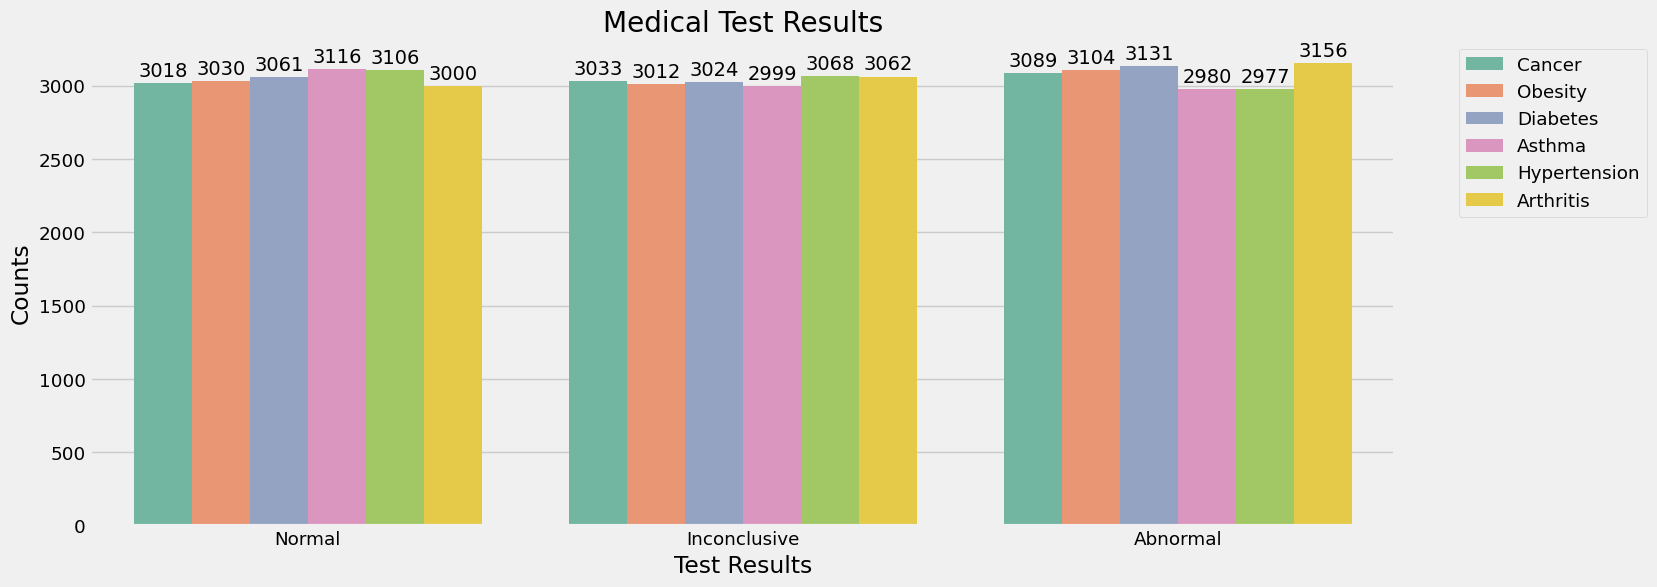

In [39]:
plt.figure(figsize=(15,6))

sns.set_context('paper', font_scale=1.5)
plt.style.use('fivethirtyeight')
ax=sns.countplot(df, x='Test Results', hue='Medical Condition', palette='Set2')
for container in ax.containers:
    ax.bar_label(container, padding=2)

plt.legend(loc='upper right', bbox_to_anchor=(1.2,1))
plt.title('Medical Test Results')
plt.ylabel('Counts')
plt.show()

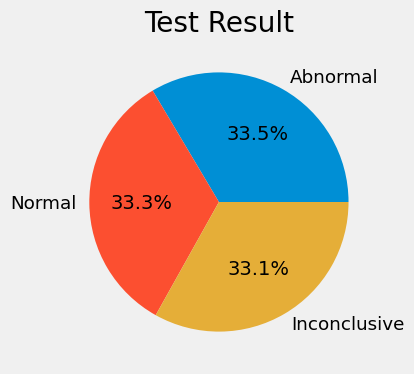

In [40]:
# Making a Pie Chart to get the Test result overall, this will help us to undertand solely the the results
plt.figure(figsize=(10,4))
df['Test Results'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Test Result")
plt.ylabel('')
plt.show()

# End of EDA

# Machine Learning

In [41]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_squared_error, r2_score

In [42]:
df.head(5)

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Months
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,1
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,8
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,9
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,11
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,9


In [43]:
X1=df[['Age','Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider', 'Billing Amount','Admission Type', "Medication"]]
y1=df['Test Results']

In [44]:
X1

,Age,Gender,Blood Type,Medical Condition,Insurance Provider,Billing Amount,Admission Type,Medication
0,30,Male,B-,Cancer,Blue Cross,18856.281306,Urgent,Paracetamol
1,62,Male,A+,Obesity,Medicare,33643.327287,Emergency,Ibuprofen
2,76,Female,A-,Obesity,Aetna,27955.096079,Emergency,Aspirin
3,28,Female,O+,Diabetes,Medicare,37909.782410,Elective,Ibuprofen
4,43,Female,AB+,Cancer,Aetna,14238.317814,Urgent,Penicillin
...,...,...,...,...,...,...,...,...
55495,42,Female,O+,Asthma,Blue Cross,2650.714952,Elective,Penicillin
55496,61,Female,AB-,Obesity,Cigna,31457.797307,Elective,Aspirin
55497,38,Female,B+,Hypertension,UnitedHealthcare,27620.764717,Urgent,Ibuprofen
55498,43,Male,O-,Arthritis,Medicare,32451.092358,Elective,Ibuprofen


In [45]:
y1

0              Normal
1        Inconclusive
2              Normal
3            Abnormal
4            Abnormal
             ...     
55495        Abnormal
55496          Normal
55497        Abnormal
55498        Abnormal
55499        Abnormal
Name: Test Results, Length: 54966, dtype: object

# Tree Based Model

In [46]:
# Tree Based models need numbers, for that reason we will encode the text like columns using Label Encoder
from sklearn.preprocessing import LabelEncoder

X1_encoded=X1.copy()
for col in X1_encoded.select_dtypes(include='object').columns:
    le= LabelEncoder()
    X1_encoded[col]=le.fit_transform(X1_encoded[col])

In [47]:
# Training Testing and Splitting 

X1_train,X1_test, y1_train,y1_test= train_test_split(X1_encoded,y1, test_size=0.20, random_state=42)

# Training Random Forest

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf= RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X1_train,y1_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [49]:
rf.score(X1_test,y1_test)

0.420138257231217

In [50]:
rf.score(X1_train,y1_train)

1.0

In [51]:
from sklearn.metrics import classification_report, confusion_matrix

y1_pred = rf.predict(X1_test)

print(classification_report(y1_test, y1_pred))
print(confusion_matrix(y1_test, y1_pred))


              precision    recall  f1-score   support

    Abnormal       0.42      0.45      0.43      3616
Inconclusive       0.42      0.40      0.41      3682
      Normal       0.42      0.41      0.42      3696

    accuracy                           0.42     10994
   macro avg       0.42      0.42      0.42     10994
weighted avg       0.42      0.42      0.42     10994

[[1617  997 1002]
 [1106 1474 1102]
 [1145 1023 1528]]


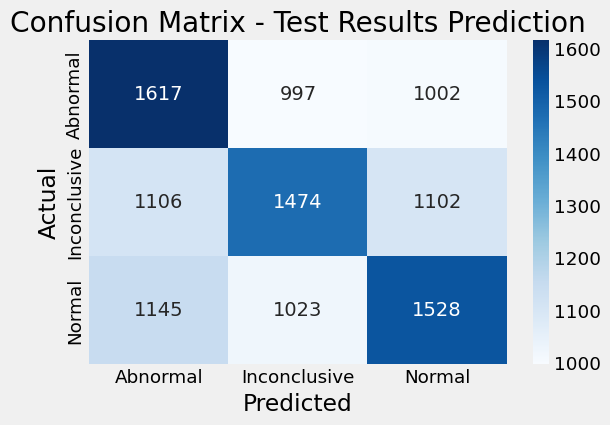

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y1_test, y1_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Test Results Prediction")
plt.show()
